In [ ]:
from model_builder import ModelBuilder
from preprocessing import Preprocessor
from plotting import Plotter
from plotting import plot_dataset
#from shapley import ProcessAttributor
from shapley_improved import ProcessAttributorSHAP
from shapley_improved import ProcessAttributorEBM
from universal_filtering import CustomSpearmanFilter
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.feature_selection import VarianceThreshold, SelectFromModel
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.base import BaseEstimator, RegressorMixin
import numpy as np

from interpret.glassbox import ExplainableBoostingRegressor

#https://ipython.org/ipython-doc/3/config/extensions/autoreload.html
%load_ext autoreload
%autoreload 2

In [2]:
train_sarek = [
    pd.read_parquet("../../../../ProcessEnergyAccounting/runs/nfcore-20260701T215234Z/datasets/sarek_1_0207.parquet"),
    pd.read_parquet("../../../../ProcessEnergyAccounting/runs/nfcore-20260702T193504Z/datasets/sarek_2_0207.parquet")
]
test_sarek = pd.read_parquet("../../../../ProcessEnergyAccounting/runs/nfcore-20260708T212252Z/datasets/sarek3_0907.parquet")


In [3]:
training_data = pd.concat(train_sarek, ignore_index=True)
training_data = training_data
test_data = test_sarek
PNG_NAME = "rf_pred_sarek"

features = [
    "delta_cpu_ns",
    "delta_io_bytes",
    "delta_net_send_bytes",
    "context_switches",
    "syscall_count",
    "delta_rss_memory",
    "delta_cpu_time_psutil",
    "delta_cpu_time_proc",
    "syscall_class_file",
    "syscall_class_network",
    "syscall_class_memory",
    "syscall_class_process",
    "syscall_class_other",
    "syscall_class_sched",
    "syscall_class_signal",
    "syscall_class_time",
    "delta_cycles",
    "delta_cache_misses",
    "delta_instructions",
    "delta_branch_instructions",
]


In [4]:
preprocessor_train = Preprocessor(training_data, features)
X_train_FULL, y_train, t_train, _ = preprocessor_train.preprocess_no_split()

Dropped 0 timestamps.


In [5]:
#plot_dataset(t_train, y_train, "multi_training")


In [6]:
#build_model = ExplainableBoostingRegressor( interactions=2, max_rounds=2000, n_jobs=-1, random_state=42)
model = RandomForestRegressor(n_estimators=100,  n_jobs=-1, random_state=42)
#build_model = MLPRegressor(activation="relu", solver="adam", random_state=42)
#model = SafeMLPWrapper()



In [7]:
#These thresholds could be fine tuned
automatic_feature_selection = Pipeline(steps=[
    ('variance', VarianceThreshold(threshold=0.01)), #explain this

    ('decorrelate', CustomSpearmanFilter(threshold=0.80)),
    ('scaler', StandardScaler()),
    ('select_features', SelectFromModel(model, threshold='0.5*median'))
])

automatic_feature_selection.set_output(transform="pandas")
automatic_feature_selection.fit_transform(X_train_FULL, y_train)
good_features = automatic_feature_selection.get_feature_names_out().tolist()
X_train = X_train_FULL[good_features]
print("Selected columns:")
print(good_features)


#plot_dataset(t_train, y_train, "multi_training")

Selected columns:
['delta_cpu_ns', 'delta_io_bytes', 'delta_net_send_bytes', 'context_switches', 'syscall_count', 'delta_rss_memory', 'delta_cpu_time_proc', 'syscall_class_file', 'syscall_class_network', 'syscall_class_memory', 'syscall_class_process', 'syscall_class_other']


In [8]:
preprocessor_test = Preprocessor(test_data, good_features)
X_test, y_test, t_test , X_test_unaggregated = preprocessor_test.preprocess_no_split()

#plot_dataset(t_test, y_test, "multi_testing")

Dropped 0 timestamps.


In [9]:
plot_dataset(t_test, y_test, "multi_testing")

In [10]:
builder_rf = ModelBuilder(X_train, X_test, y_train, y_test, model, StandardScaler())
y_pred_rf, learned_idle_power = builder_rf.run_and_save_model()


  R² Score:  0.9292
  MAE:       5.17 Wh (2.57% of mean)
----------------------------------
The model's learned baseline idle interval energy is: 141.68 Wh
----------------------------------
/n


In [11]:
y_pred_rf

array([141.20798731, 140.64667468, 141.67752933, ..., 143.87889117,
       144.74334963, 143.84358341], shape=(8338,))

In [12]:
plotter = Plotter(y_pred_rf,y_test, t_test)#, window_start =50, window_end=200)
plotter.plot_and_save("", PNG_NAME)

SHAP Base Power (Idle Baseline): 141.68 Ws
actually aligned timezones
Top processes:  Index(['python', 'java', 'bwa', 'influxd', 'samtools', 'EstimateSVLoci',
       'freebayes', 'strelka2'],
      dtype='object', name='base_name')
Top processes:  Index(['python', 'java', 'bwa', 'influxd', 'samtools', 'EstimateSVLoci',
       'freebayes', 'strelka2'],
      dtype='object', name='base_name')


,pid,process_name,avg_power,context_switches,create_time,delta_branch_instructions,delta_cache_misses,delta_cpu_ns,delta_cpu_time_proc,delta_cpu_time_psutil,...,syscall_class_process,syscall_class_signal,syscall_class_sched,syscall_class_time,syscall_class_memory,cgroup,cmdline,cwd,exe,attributed_dynamic_Wh
_time,,,,,,,,,,,,,,,,,,,,,
2026-07-08 21:22:53+00:00,1,systemd,69.0,0.0,-1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,NaN,NaN,NaN,0.0,None,None,None,None,0.000000
2026-07-08 21:22:53+00:00,3399337,libuv-worker,69.0,0.0,-1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,NaN,NaN,NaN,0.0,None,None,None,None,0.000000
2026-07-08 21:22:53+00:00,3399380,MainThread,69.0,0.0,-1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,NaN,NaN,0.0,None,None,None,None,0.000000
2026-07-08 21:22:53+00:00,34,ksoftirqd/3,69.0,0.0,-1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,NaN,NaN,NaN,0.0,None,None,None,None,0.000000
2026-07-08 21:22:53+00:00,3404621,kworker/u96:0-events_unbound,69.0,144.0,-1.0,0.0,0.0,1035885.0,0.0,0.0,...,0.0,NaN,NaN,NaN,0.0,None,None,None,None,-0.011858
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-07-09 02:56:11+00:00,235127,kworker/0:1-rcu_par_gp,71.0,0.0,-1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,NaN,NaN,NaN,0.0,None,None,None,None,0.000000
2026-07-09 02:56:11+00:00,234219,kworker/2:2-rcu_par_gp,71.0,0.0,-1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,NaN,NaN,NaN,0.0,None,None,None,None,0.000000
2026-07-09 02:56:11+00:00,234074,kworker/27:1-rcu_par_gp,71.0,0.0,-1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,NaN,NaN,NaN,0.0,None,None,None,None,0.000000


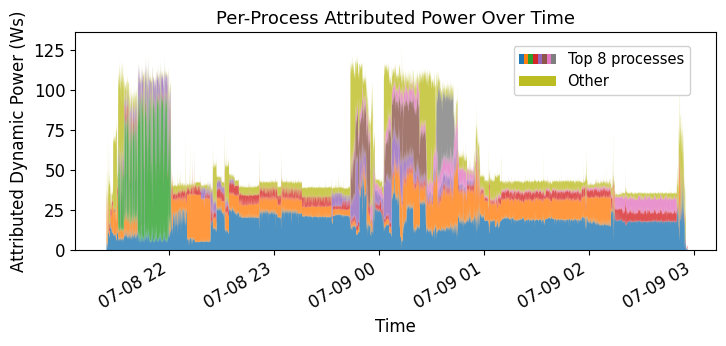

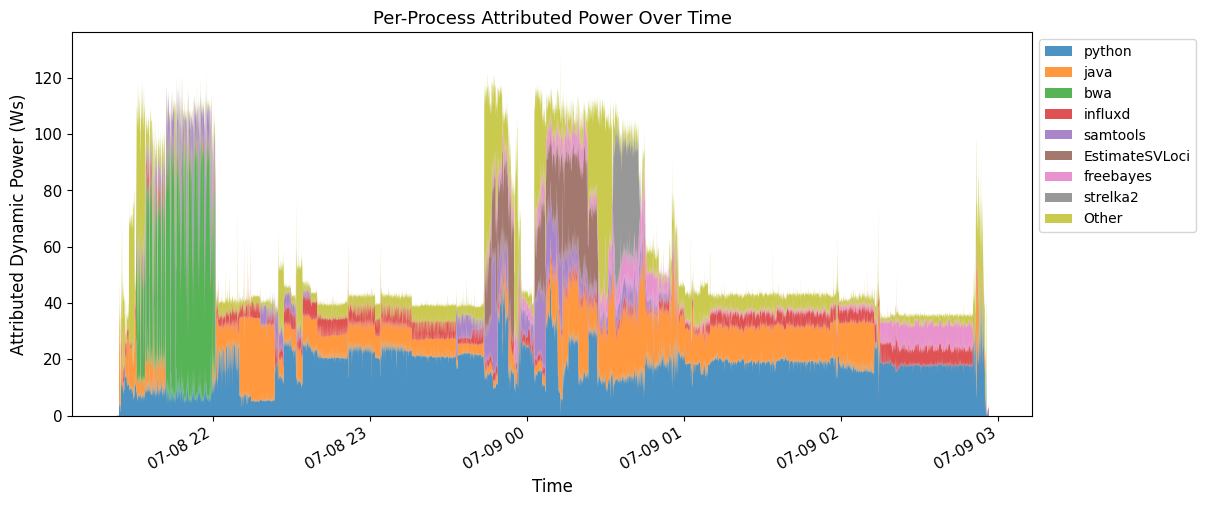

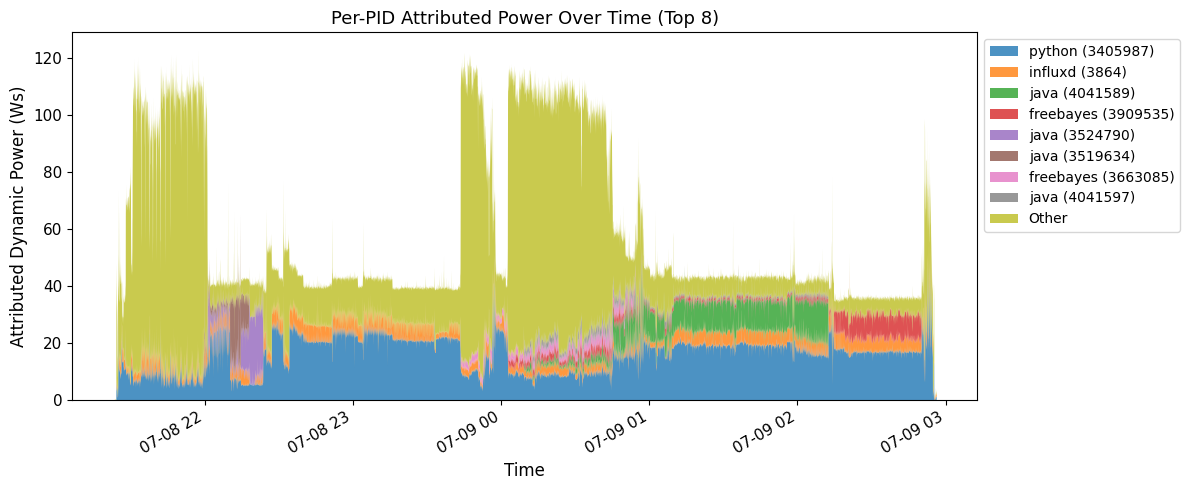

In [13]:
#check if we ann pass this differently
attributor = ProcessAttributorSHAP( builder_rf.X_test_scaled, builder_rf.model, builder_rf.scaler)
attributor.attribute(X_test_unaggregated,good_features,t_test.values, "rf_graphs_")